# GISLR — Streaming confidence: is mid-sequence evidence usable, and does reset help?

**What this notebook does.** Diagnostic, not a pipeline stage — it answers the
two open questions TODO's Backlog item ("Live, per-frame-updating streaming
prediction with reset-on-accept") and the architecture discussion around it
left unresolved, using checkpoints that already exist (no training here):

1. **Phase A — is per-frame confidence already usable, or garbage?**
   `gru`/`lstm`/`cnn`/`dnn` are all trained with a loss at the LAST valid
   frame only (`bilstm` excluded entirely — offline-only, no causal per-frame
   readout, see `sb.recognize.architectures.BiLSTM`'s docstring). Nothing
   supervises what the running prediction looks like mid-sequence. This
   section measures it directly instead of assuming either answer.
2. **Phase B — does explicit state reset actually help, and does the
   mechanism work?** Neither GISLR nor POPSIGN has real multi-sign sequences
   (the same data gap TODO §8 flags for a sentence-context LLM), so this
   builds synthetic continuous streams by concatenating isolated clips with
   known boundaries, measures how much a `gru`/`lstm`'s carried hidden state
   "bleeds" the old sign's confidence into the next one, and verifies that
   `sb.recognize.streaming.RecurrentSession.reset()` — the actual mechanism a
   live caller would use — clears it. A rule-based `AcceptTrigger` sweep
   (threshold + hold-duration) is included as the Phase D scaffold: a
   fixed-rule reset decision-maker to validate the mechanism against, before
   any LLM (Phase E) decides when to pull it.

**Models used**: the `gru`/`lstm`/`cnn`/`dnn` checkpoints from
`gislr.1.models.five-arch-benchmark.ipynb` (`data/cache/gislr/five_arch_benchmark_runs/`)
— already trained, identical feature pipeline (`base_v1`, ME-126/xy, 252-dim),
identical regime. Reused rather than retrained: this notebook measures an
inference-time property, not a training outcome. `bilstm` is loaded nowhere
here (see above); it stays a plan-1 latency/accuracy reference only.

**Design decisions vs the streaming Backlog item:**
- "Confidence reset" and "hidden-state reset" are kept as two different
  things throughout: `gru`/`lstm` reset an actual internal state
  (`RecurrentSession.reset`); `cnn`/`dnn` have no persistent state to reset
  at all (`cnn` is a finite receptive field, `dnn` is exactly memory-free per
  frame) and are included here as **no-memory controls**, not as reset
  candidates.
- The incremental step-by-step API (`RecurrentSession`) and the fast batch
  readout used for bulk analysis (`per_frame_probs`) are cross-checked for
  numerical parity (§5) before either is trusted — they must agree, since
  they compute the same thing two different ways.
- This is a notebook-based simulation over recorded landmark data, not a live
  camera/app loop (`CLAUDE.md`: no app in this repo yet) — §10.2's livestream
  mode is a separate, later concern.

**Artifacts:**

| path | what |
|---|---|
| `data/cache/gislr/streaming_confidence_eval/streams/<i>.npz` | one synthetic continuous stream (concatenated clip array + labels + boundaries) |
| `data/cache/gislr/streaming_confidence_eval/streams_manifest.json` | resumable manifest for stream construction |
| `data/cache/gislr/streaming_confidence_eval/position_confidence.csv` | Phase A: mean true-class confidence by relative position-in-clip, per arch |
| `data/cache/gislr/streaming_confidence_eval/boundary_effect.csv` | Phase B: re-acquisition latency / bleed-through, with vs without reset |
| `data/cache/gislr/streaming_confidence_eval/trigger_sweep.csv` | Phase D: `AcceptTrigger` (tau, hold_frames) sweep results |
| a few inline confidence-trajectory plots (not saved as files — this is a diagnostic, not a report asset factory) |

**Resumability**: stream construction is manifest-driven (§2, same
write-artifact-before-marking-done pattern as `gislr.0.dataset.motion-energy.ipynb`).
Everything downstream (§3 onward) reads the cached streams and re-runs cheaply
in seconds — no manifest needed there.

**Not in scope here** (filed as later TODO Plan 2 phases): retraining with a
per-frame-supervised auxiliary loss (Phase C — gated on what §4 finds below),
and anything involving an LLM (Phase E — also needs TODO §8's
next-word-suggestion data-source question answered first).


## Setup

In [1]:
# ============================================================
# Imports, tunables, resolved paths
# ============================================================
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from sb.core.paths import CACHE_DIR, EXPERIMENTS_DIR
from sb.core.subsets import SUBSETS
from sb.recognize.architectures import CausalConv1D, StreamingGRU, StreamingLSTM
from sb.recognize.features import base_v1 as BFEAT
from sb.recognize.interp.models import LandmarkDNN
from sb.recognize.interp.train import load_split_arrays
from sb.recognize.sources import get_source
from sb.recognize.streaming import (
    AcceptTrigger,
    RecurrentSession,
    build_synthetic_stream,
    per_frame_probs,
)

SEED = 42
RNG = np.random.default_rng(SEED)

ARCHES = ["gru", "lstm", "cnn", "dnn"]  # bilstm excluded -- see title cell
N_STREAMS = 30           # synthetic continuous streams to build
CLIPS_PER_STREAM = 4     # isolated clips concatenated per stream
N_EXEMPLAR_PLOTS = 3     # how many streams to plot in full in §4

TAU_GRID = [0.5, 0.7, 0.9]
HOLD_FRAMES_GRID = [3, 5, 10]

FIVE_ARCH_ROOT = CACHE_DIR / "gislr" / "five_arch_benchmark_runs"
CONFIG_PATH = EXPERIMENTS_DIR / "recognition" / "configs" / "gislr.five-arch-benchmark.json"
CONFIG = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
HYP = CONFIG["shared"]
ME_126 = SUBSETS["ME_126"]
FEATURE_DIM = len(ME_126) * 2  # xy only, matches the five-arch-benchmark pipeline

OUT_ROOT = CACHE_DIR / "gislr" / "streaming_confidence_eval"
STREAMS_DIR = OUT_ROOT / "streams"
STREAMS_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_PATH = OUT_ROOT / "streams_manifest.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"five-arch checkpoints: {FIVE_ARCH_ROOT}")
print(f"output root: {OUT_ROOT}")
print(f"feature_dim={FEATURE_DIM}  device={DEVICE}")


five-arch checkpoints: C:\Users\user2\repository\data\cache\gislr\five_arch_benchmark_runs
output root: C:\Users\user2\repository\data\cache\gislr\streaming_confidence_eval
feature_dim=252  device=cuda


## 1. Load the four checkpoints (no training)

Reconstructs each architecture from `gislr.five-arch-benchmark.json` (the
same config `gislr.1.models.five-arch-benchmark.ipynb` trained with) and loads
each run's `best_state` — the best-internal-val-accuracy weights, the same
ones that notebook reports its verdict numbers from. If a checkpoint is
missing, re-run that notebook's §3 first; this notebook does not train
anything.

In [2]:
# ============================================================
# Canonical split + label map (needed for N_CLASSES and to sample real clips)
# ============================================================
ds = get_source("gislr")
DATA_DIR = ds.resolve_dir()
sign2idx = ds.label_map(DATA_DIR)
idx2sign = {v: k for k, v in sign2idx.items()}
N_CLASSES = len(sign2idx)
_, test_split = ds.canonical_split(DATA_DIR, sign2idx)
print(f"test.csv: {len(test_split)} videos, {N_CLASSES} classes")

te_data_path, te_off_path = BFEAT.build_cache(
    test_split, "test", ME_126, "xy", DATA_DIR
)  # skip-if-exists -- already built by the five-arch-benchmark notebook
test_data, test_off, test_labels = load_split_arrays(te_data_path, te_off_path, test_split)


def hyp_for_arm(arm: str) -> dict:
    return {**HYP, **CONFIG["architectures"][arm].get("overrides", {})}


def make_model(arm: str) -> torch.nn.Module:
    arm_hyp = hyp_for_arm(arm)
    if arm == "gru":
        return StreamingGRU(FEATURE_DIM, arm_hyp["hidden_size"], arm_hyp["num_layers"],
                            N_CLASSES, arm_hyp["dropout"])
    if arm == "lstm":
        return StreamingLSTM(FEATURE_DIM, arm_hyp["hidden_size"], arm_hyp["num_layers"],
                             N_CLASSES, arm_hyp["dropout"])
    if arm == "cnn":
        return CausalConv1D(FEATURE_DIM, arm_hyp["hidden_size"], arm_hyp["num_layers"],
                            N_CLASSES, arm_hyp["dropout"])
    return LandmarkDNN(
        hidden_sizes=tuple(CONFIG["architectures"]["dnn"]["hidden_sizes"]),
        num_classes=N_CLASSES, dropout=arm_hyp["dropout"],
        n_landmarks=len(ME_126), channels_per_landmark=2, angle_dim=0, relational_dim=0,
    )


models = {}
for arm in ARCHES:
    ckpt_path = FIVE_ARCH_ROOT / arm / "final.pt"
    assert ckpt_path.is_file(), f"missing checkpoint: {ckpt_path} -- run the five-arch-benchmark notebook first"
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model = make_model(arm).to(DEVICE)
    model.load_state_dict(ckpt["best_state"])
    model.eval()
    models[arm] = model
    print(f"{arm}: loaded best_state, best_val_acc={ckpt['best_val_acc']:.4f}")


test.csv: 18896 videos, 250 classes
gru: loaded best_state, best_val_acc=0.7291
lstm: loaded best_state, best_val_acc=0.7341
cnn: loaded best_state, best_val_acc=0.6688
dnn: loaded best_state, best_val_acc=0.6476


## 2. Build synthetic continuous streams (resumable)

Neither GISLR nor POPSIGN has real multi-sign sequences, so this concatenates
`CLIPS_PER_STREAM` randomly sampled `test.csv` clips end-to-end per stream, no
gap between them, and records the true label + start frame of each segment.
Seeded and cached per §1.2's manifest pattern: each stream is written to disk
before being marked `done`, so an interrupted run resumes rather than
re-sampling.

In [3]:
# ============================================================
# Synthetic stream construction -- manifest-driven, resumable
# ============================================================
def load_manifest() -> dict:
    if MANIFEST_PATH.is_file():
        return json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
    return {"done": {}, "seed": SEED, "clips_per_stream": CLIPS_PER_STREAM}


def save_manifest(manifest: dict) -> None:
    tmp = MANIFEST_PATH.with_suffix(".json.tmp")
    tmp.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    tmp.replace(MANIFEST_PATH)


def load_clip(row: int) -> np.ndarray:
    """One test-split video's cached (T, feature_dim) array, already
    NaN->0'd and subset-selected -- same slicing as SubsetArrayDataset,
    but WITHOUT the MAX_SEQ_LEN subsample: a full-length clip is more honest
    for a streaming boundary-effect measurement than a subsampled one."""
    d = FEATURE_DIM
    arr = test_data[test_off[row] * d: test_off[row + 1] * d].reshape(-1, d)
    return np.ascontiguousarray(arr)


manifest = load_manifest()
stream_rng = np.random.default_rng(SEED)
for i in tqdm(range(N_STREAMS), desc="synthetic streams"):
    key = str(i)
    if key in manifest["done"]:
        continue
    rows = stream_rng.choice(len(test_split), size=CLIPS_PER_STREAM, replace=False)
    clips = [load_clip(int(r)) for r in rows]
    labels = [int(test_labels[int(r)]) for r in rows]
    concat, boundaries, lengths = build_synthetic_stream(clips)
    out_path = STREAMS_DIR / f"{i}.npz"
    # np.savez_compressed silently APPENDS ".npz" to any filename that doesn't
    # already end with it -- naming the tmp file "<i>.npz.tmp" would actually
    # write "<i>.npz.tmp.npz", and the rename below would then fail to find
    # it. Keep the tmp file ending in ".npz" so numpy writes exactly that path.
    tmp_path = out_path.with_name(f"{i}.tmp.npz")
    np.savez_compressed(tmp_path, data=concat.astype(np.float32),
                        boundaries=np.asarray(boundaries), lengths=np.asarray(lengths),
                        labels=np.asarray(labels))
    tmp_path.replace(out_path)
    manifest["done"][key] = {"rows": [int(r) for r in rows], "n_frames": int(concat.shape[0])}
    save_manifest(manifest)

print(f"{len(manifest['done'])}/{N_STREAMS} streams ready in {STREAMS_DIR}")


synthetic streams:   0%|          | 0/30 [00:00<?, ?it/s]

30/30 streams ready in C:\Users\user2\repository\data\cache\gislr\streaming_confidence_eval\streams


## 3. Phase A — per-frame true-class confidence by position in clip

For each stream, each architecture, and each concatenated clip segment: run
`per_frame_probs` once over the whole stream, then read off the confidence the
model assigned to that segment's OWN true label at every one of its frames.
Binned into thirds (early / mid / late) of each clip's own length — the
direct answer to "is mid-sequence confidence already usable, or garbage until
the sign is nearly over?".

In [4]:
# ============================================================
# Per-frame true-class confidence, binned by relative position in clip
# ============================================================
def load_stream(i: int) -> dict:
    z = np.load(STREAMS_DIR / f"{i}.npz")
    return {"data": z["data"], "boundaries": z["boundaries"].tolist(),
            "lengths": z["lengths"].tolist(), "labels": z["labels"].tolist()}


position_rows = []
for i in tqdm(range(N_STREAMS), desc="Phase A: position-binned confidence"):
    stream = load_stream(i)
    x = torch.from_numpy(stream["data"])
    for arch in ARCHES:
        probs = per_frame_probs(models[arch], arch, x)  # (T, C)
        for start, length, label in zip(stream["boundaries"], stream["lengths"], stream["labels"]):
            true_conf = probs[start:start + length, label]
            thirds = np.array_split(true_conf, 3)
            for third_name, vals in zip(["early", "mid", "late"], thirds):
                if len(vals):
                    position_rows.append({"arch": arch, "stream": i, "third": third_name,
                                          "mean_true_class_conf": float(vals.mean())})

position_df = pd.DataFrame(position_rows)
position_summary = (position_df.groupby(["arch", "third"])["mean_true_class_conf"]
                    .agg(["mean", "std"]).reset_index())
position_summary.to_csv(OUT_ROOT / "position_confidence.csv", index=False)
position_summary.pivot(index="arch", columns="third", values="mean").reindex(columns=["early", "mid", "late"])


Phase A: position-binned confidence:   0%|          | 0/30 [00:00<?, ?it/s]

third,early,mid,late
arch,,,
cnn,0.063031,0.163236,0.269703
dnn,0.200088,0.238587,0.249332
gru,0.047674,0.141521,0.211982
lstm,0.059328,0.154998,0.228298


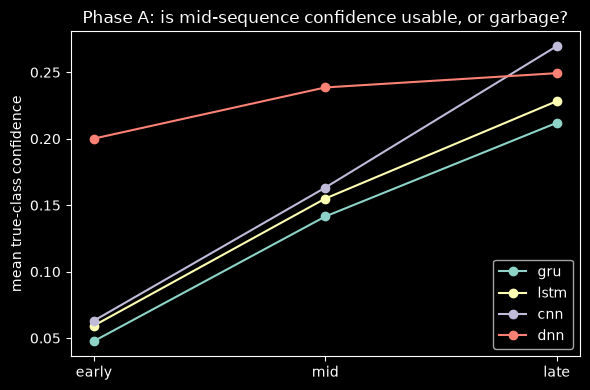

In [5]:
# ============================================================
# Plot: mean true-class confidence by relative position, one line per arch
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))
for arch in ARCHES:
    sub = position_summary[position_summary["arch"] == arch].set_index("third").reindex(["early", "mid", "late"])
    ax.plot(["early", "mid", "late"], sub["mean"], marker="o", label=arch)
ax.set_ylabel("mean true-class confidence")
ax.set_title("Phase A: is mid-sequence confidence usable, or garbage?")
ax.legend()
fig.tight_layout()
plt.show()


## 4. Exemplar confidence trajectories

A few whole streams, plotted frame-by-frame, per architecture — vertical
lines mark the true clip boundaries. Read alongside §3's aggregate: this
shows *shape* (a ramp? a spike only at the very end? noise throughout?) that
a mean-by-third can hide.

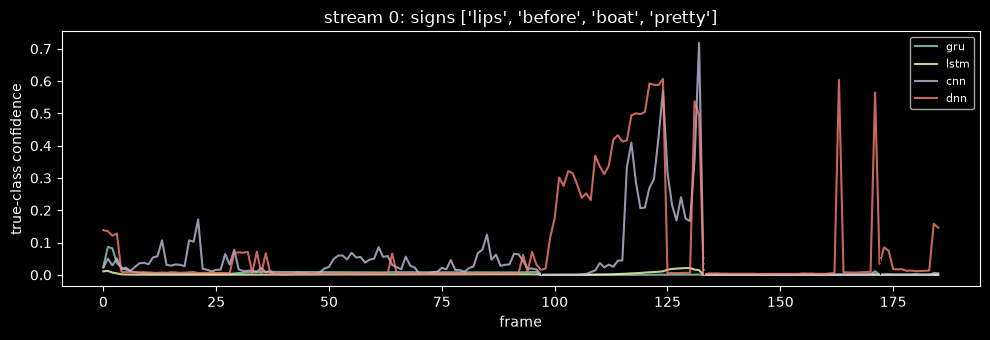

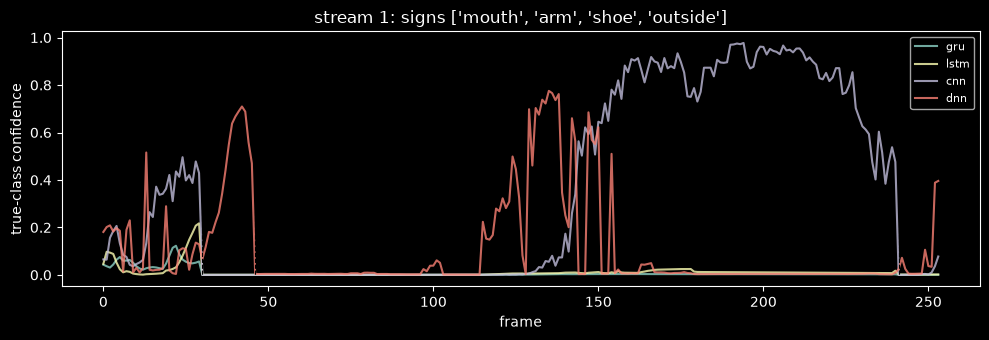

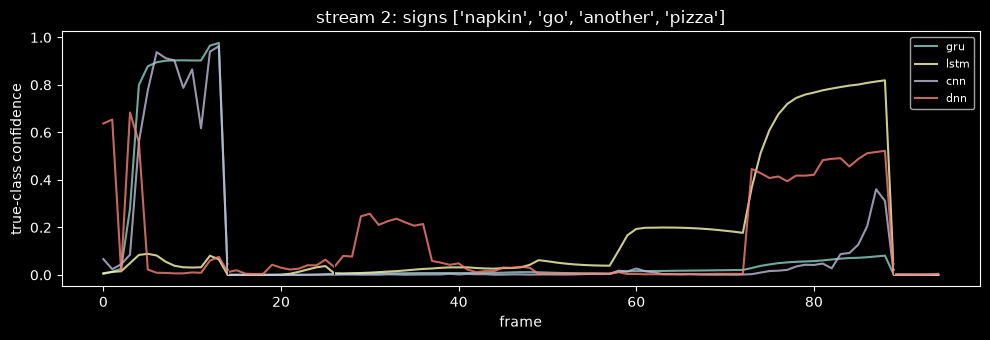

In [6]:
# ============================================================
# Exemplar plots
# ============================================================
for i in range(min(N_EXEMPLAR_PLOTS, N_STREAMS)):
    stream = load_stream(i)
    x = torch.from_numpy(stream["data"])
    fig, ax = plt.subplots(figsize=(10, 3.5))
    for arch in ARCHES:
        probs = per_frame_probs(models[arch], arch, x)
        # true-class confidence at every frame, using whichever segment that frame belongs to
        true_conf = np.zeros(len(probs))
        for start, length, label in zip(stream["boundaries"], stream["lengths"], stream["labels"]):
            true_conf[start:start + length] = probs[start:start + length, label]
        ax.plot(true_conf, label=arch, alpha=0.8)
    for b in stream["boundaries"][1:]:
        ax.axvline(b, color="black", ls="--", lw=0.8)
    ax.set_title(f"stream {i}: signs {[idx2sign[l] for l in stream['labels']]}")
    ax.set_xlabel("frame"); ax.set_ylabel("true-class confidence"); ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


## 5. Parity check — does the true incremental API match the batch readout?

`RecurrentSession.step` is what a live caller would actually use; `per_frame_probs`
is the fast batch path used above. They compute the same thing two different
ways (packed-free full-sequence forward vs. one frame at a time with carried
state) and must agree numerically before either is trusted for the boundary
analysis in §6.

In [ ]:
# ============================================================
# Parity: RecurrentSession stepped one frame at a time vs per_frame_probs
#
# Checked on CPU, deliberately -- on GPU, cuDNN dispatches a DIFFERENT kernel
# for a whole-sequence GRU/LSTM call than for a loop of single-frame calls,
# so the two accumulate divergent floating-point error over enough frames
# (measured ~5e-4 max abs diff after ~80 frames on this checkpoint) even
# though they compute the same mathematical recurrence. That is a real
# GPU-numerics fact, not a bug in RecurrentSession -- but it also means a
# GPU parity check can't tell a genuine implementation bug apart from
# ordinary kernel-selection noise. CPU's GRU/LSTM path is a straightforward
# step-by-step loop with no such kernel-selection dependence, so it is the
# actual test of whether the two computations agree.
# ============================================================
stream0 = load_stream(0)
x0_cpu = torch.from_numpy(stream0["data"])

for arch in ["gru", "lstm"]:
    models[arch].cpu()
    batch_probs = per_frame_probs(models[arch], arch, x0_cpu)
    session = RecurrentSession(models[arch], arch, device=torch.device("cpu"))
    stepped = np.stack([session.step(x0_cpu[t]) for t in range(x0_cpu.shape[0])])
    max_abs_diff = np.abs(batch_probs - stepped).max()
    print(f"{arch}: max |batch - stepped| = {max_abs_diff:.2e}")
    assert max_abs_diff < 1e-4, f"{arch}: incremental session does not match batch readout"
    models[arch].to(DEVICE)  # restore for the GPU-accelerated cells below
print("parity OK -- RecurrentSession.step reproduces per_frame_probs frame-for-frame")

## 6. Phase B — does resetting hidden state at the boundary actually help?

For `gru`/`lstm` only (the two architectures with carried state to leak or
clear). At each synthetic boundary, two conditions:

- **no reset**: state carries across the boundary untouched (what happens
  today if nothing resets it).
- **oracle reset**: `RecurrentSession.reset()` called exactly at the true
  boundary (the mechanism working perfectly, decision-maker aside).

Two measurements per boundary: **bleed-through** (how many frames after the
boundary the OLD label's confidence stays above the NEW label's) and
**re-acquisition latency** (how many frames until the NEW label's confidence
first exceeds 0.5).

In [ ]:
# ============================================================
# Boundary effect: no-reset vs oracle-reset, gru/lstm only
# ============================================================
def boundary_metrics(probs: np.ndarray, boundaries, lengths, labels) -> list[dict]:
    rows = []
    for k in range(1, len(boundaries)):  # skip the first boundary -- nothing precedes it
        b = boundaries[k]
        old_label, new_label = labels[k - 1], labels[k]
        seg_len = lengths[k]
        bleed = 0
        for t in range(b, min(b + seg_len, len(probs))):
            if probs[t, old_label] > probs[t, new_label]:
                bleed += 1
            else:
                break
        latency = seg_len  # default: never reacquired within this segment
        for t in range(b, min(b + seg_len, len(probs))):
            if probs[t, new_label] > 0.5:
                latency = t - b
                break
        rows.append({"bleed_through_frames": bleed, "reacquire_latency_frames": latency})
    return rows


boundary_rows = []
for i in tqdm(range(N_STREAMS), desc="Phase B: boundary effect"):
    stream = load_stream(i)
    x = torch.from_numpy(stream["data"]).to(DEVICE)
    for arch in ["gru", "lstm"]:
        # no-reset: exactly per_frame_probs's own carried-state computation
        no_reset_probs = per_frame_probs(models[arch], arch, x.cpu())
        for row in boundary_metrics(no_reset_probs, stream["boundaries"], stream["lengths"], stream["labels"]):
            boundary_rows.append({"arch": arch, "stream": i, "condition": "no_reset", **row})

        # oracle reset: step through with RecurrentSession, reset() at every true boundary
        session = RecurrentSession(models[arch], arch, device=DEVICE)
        reset_probs = np.zeros((x.shape[0], N_CLASSES), dtype=np.float32)
        boundary_set = set(stream["boundaries"])
        for t in range(x.shape[0]):
            if t in boundary_set and t > 0:
                session.reset()
            reset_probs[t] = session.step(x[t])
        for row in boundary_metrics(reset_probs, stream["boundaries"], stream["lengths"], stream["labels"]):
            boundary_rows.append({"arch": arch, "stream": i, "condition": "oracle_reset", **row})

boundary_df = pd.DataFrame(boundary_rows)
boundary_summary = boundary_df.groupby(["arch", "condition"])[
    ["bleed_through_frames", "reacquire_latency_frames"]
].mean().reset_index()
boundary_summary.to_csv(OUT_ROOT / "boundary_effect.csv", index=False)
boundary_summary


## 7. Phase D scaffold — rule-based `AcceptTrigger` sweep

With oracle reset applied at the true boundaries (isolating trigger quality
from reset-mechanism correctness, per §6), sweep `(tau, hold_frames)` and
measure: does the trigger fire near the true boundary, on the correct label,
and how often does it false-fire mid-clip? This is the fixed-rule baseline
Plan 2 said to validate before an LLM (Phase E) becomes the decision-maker.

In [ ]:
# ============================================================
# AcceptTrigger sweep -- gru/lstm, oracle-reset streams
# ============================================================
trigger_rows = []
for tau in TAU_GRID:
    for hold in HOLD_FRAMES_GRID:
        for arch in ["gru", "lstm"]:
            n_correct, n_false, n_missed, n_total_boundaries = 0, 0, 0, 0
            for i in range(N_STREAMS):
                stream = load_stream(i)
                x = torch.from_numpy(stream["data"]).to(DEVICE)
                session = RecurrentSession(models[arch], arch, device=DEVICE)
                trigger = AcceptTrigger(tau=tau, hold_frames=hold)
                boundary_set = set(stream["boundaries"])
                seg_idx, fired_this_seg = 0, False
                seg_ends = list(stream["boundaries"][1:]) + [x.shape[0]]
                for t in range(x.shape[0]):
                    if t in boundary_set and t > 0:
                        session.reset()
                    if t >= seg_ends[seg_idx]:
                        if not fired_this_seg:
                            n_missed += 1
                        seg_idx += 1
                        fired_this_seg = False
                    probs = session.step(x[t])
                    accepted = trigger.update(probs)
                    if accepted is not None:
                        if accepted == stream["labels"][seg_idx]:
                            n_correct += 1
                        else:
                            n_false += 1
                        fired_this_seg = True
                if not fired_this_seg:
                    n_missed += 1
                n_total_boundaries += len(stream["boundaries"])
            trigger_rows.append({
                "arch": arch, "tau": tau, "hold_frames": hold,
                "correct_accepts": n_correct, "wrong_accepts": n_false,
                "missed_segments": n_missed, "n_segments": n_total_boundaries,
            })

trigger_df = pd.DataFrame(trigger_rows)
trigger_df["accept_precision"] = trigger_df["correct_accepts"] / (
    trigger_df["correct_accepts"] + trigger_df["wrong_accepts"]).replace(0, np.nan)
trigger_df.to_csv(OUT_ROOT / "trigger_sweep.csv", index=False)
trigger_df.sort_values(["arch", "accept_precision"], ascending=[True, False])


## 8. Verdict (fill in after running)

Fill in against the questions this notebook was built to answer:

- **Phase A**: does true-class confidence rise from early → late within a
  clip (usable evidence accumulating), or is it flat/noisy until the end
  (meaning Plan 2 Phase C's per-frame-supervised retrain is a prerequisite,
  not an optional refinement)?
- **Phase B**: how much does oracle reset reduce bleed-through and
  re-acquisition latency vs no reset, for `gru` and `lstm` respectively?
- **Phase D**: which `(tau, hold_frames)` gives the best accept-precision
  without missing too many segments — and is a fixed rule good enough, or is
  this where the case for an LLM decision-maker (Phase E) actually gets
  stronger?

Artifacts: `position_confidence.csv`, `boundary_effect.csv`, `trigger_sweep.csv`
in `data/cache/gislr/streaming_confidence_eval/`.
